In [1]:
import pandas as pd

df = pd.read_csv('/content/Housing.csv')
print("DataFrame 'df' loaded successfully. Displaying the first 5 rows:")
df.head()

DataFrame 'df' loaded successfully. Displaying the first 5 rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [2]:
print("Displaying the first 5 rows of the DataFrame:")
display(df.head())

print("\nDataFrame Information (data types, non-null counts):")
df.info()

print("\nDescriptive statistics for numerical columns:")
display(df.describe())

Displaying the first 5 rows of the DataFrame:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



DataFrame Information (data types, non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB

Descriptive statistics for numerical columns:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [3]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('price', axis=1)
y = df['price']

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Apply one-hot encoding to categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Shape of X after one-hot encoding:", X_encoded.shape)
print("First 5 rows of X_encoded:")
display(X_encoded.head())

Shape of X after one-hot encoding: (545, 13)
First 5 rows of X_encoded:


,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,7420,4,1,2,2,True,True,True,False,True,False,False,False


## Model Training - Linear Regression

I will now fit a Linear Regression model to the training data (`X_train`, `y_train`). This model will learn the relationship between the features and the target variable (price).

In [8]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

print("Linear Regression model fitted successfully.")

Linear Regression model fitted successfully.


### Split the data into training and testing sets

Now that the categorical features are encoded, I will split the data into training and testing sets. A common split ratio is 70% for training and 30% for testing. `random_state` is set for reproducibility.

In [7]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (381, 13)
X_test shape: (164, 13)
y_train shape: (381,)
y_test shape: (164,)


In [9]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Fit the model on training data
model.fit(X_train, y_train)

print("Linear Regression model fitted successfully.")


Linear Regression model fitted successfully.


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)


Mean Absolute Error (MAE): 920392.9397607957
Mean Squared Error (MSE): 1523019469501.2913
R² Score: 0.6463350878895877


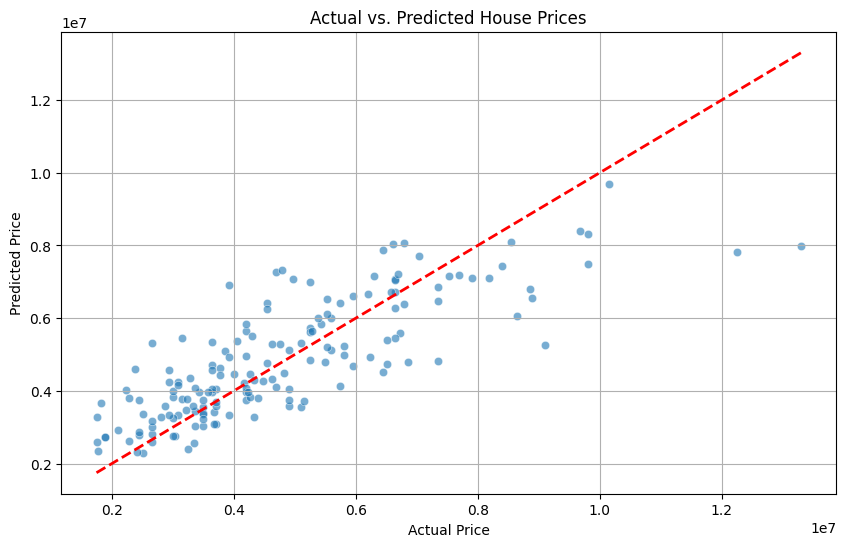


--- Model Coefficients ---


,Feature,Coefficient
0,area,2.532873e+02
1,bedrooms,8.089314e+04
2,bathrooms,1.114751e+06
3,stories,4.172676e+05
4,parking,3.031112e+05
5,mainroad_yes,4.080737e+05
6,guestroom_yes,2.757105e+05
7,basement_yes,4.826035e+05
8,hotwaterheating_yes,6.163754e+05
9,airconditioning_yes,6.858393e+05



Intercept: 95784.2291119732


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Red dashed line for perfect prediction
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted House Prices")
plt.grid(True)
plt.show()

print("\n--- Model Coefficients ---")
# Create a DataFrame to display coefficients with their corresponding feature names
coefficients_df = pd.DataFrame({'Feature': X_encoded.columns, 'Coefficient': model.coef_})
display(coefficients_df)

print("\nIntercept:", model.intercept_)